# Employee Attrition Predictor

This project analyzes historical workforce data to predict employee attrition.
The objective is to build a machine learning classification model that identifies high risks departments and roles
Allows the organization to deploy targeted , data driven retention strategies.

In [1]:
import pandas as pd
import numpy as np
from google.colab import files


In [2]:
print("Awaiting HR dataset CSV upload...")
uploaded_file = files.upload()

Awaiting HR dataset CSV upload...


Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv


In [3]:
file_name = next(iter(uploaded_file))

In [4]:
workforce_data = pd.read_csv(file_name)

In [5]:
print(f"\n[SYSTEM STATUS] Data Ingestion Complete.")
print(f"-> Total Employee Records Processed: {workforce_data.shape[0]}")
print(f"-> Feature Columns Available: {workforce_data.shape[1]}")


[SYSTEM STATUS] Data Ingestion Complete.
-> Total Employee Records Processed: 1470
-> Feature Columns Available: 35


In [6]:
workforce_data.head(3)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0


# Exploratory Data Analysis & Data Integrity

 Verify data quality and remove zero-variance features.
 Columns like 'EmployeeCount' , 'Over18' , 'StandardHours' contain the exact value for every single employee,meaning they offer zero predictive value to a machine learning model.
  'EmployeeNumber' is a randomly assigned ID and must also be removed to prevent the algorithm from finding false mathematical patterns.

In [7]:
missing_data = workforce_data.isnull().sum().sum()
print(f"[DATA INTEGRITY CHECK] Total Missing Values Found: {missing_data}")

columns_to_drop = ['EmployeeCount' , 'Over18' , 'StandardHours' , 'EmployeeNumber']
workforce_data = workforce_data.drop(columns =columns_to_drop)

print(f"[SYSTEM STATUS] Succesfully dropped {len(columns_to_drop)} non-predictive columns.")
print(f"-> Remaining Predictive Features: {workforce_data.shape[1]}")

[DATA INTEGRITY CHECK] Total Missing Values Found: 0
[SYSTEM STATUS] Succesfully dropped 4 non-predictive columns.
-> Remaining Predictive Features: 31


# Attrition Distribution Analysis

Visualizing the baseline employee turnover rate and isolating it by department to identify which organizational areas are at the highest risk of talent depletion.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns



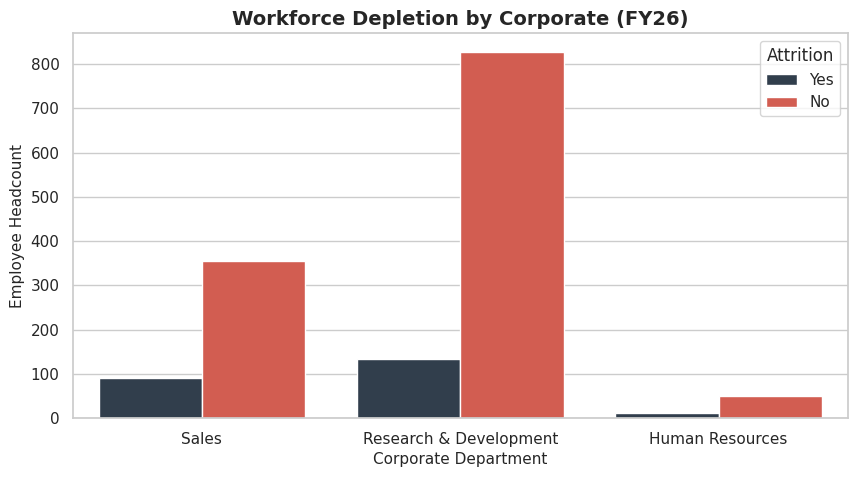

In [9]:
sns.set_theme(style = "whitegrid")
enterprise_palette = ["#2c3e50" , "#e74c3c"]
plt.figure(figsize = (10,5))
ax = sns.countplot(data = workforce_data , x = 'Department' , hue = 'Attrition' , palette = enterprise_palette)

plt.title("Workforce Depletion by Corporate (FY26)" , fontsize=14 , fontweight= 'bold')
plt.xlabel("Corporate Department" , fontsize=11)
plt.ylabel("Employee Headcount" , fontsize=11)

plt.show()


# Feature Engineering & Mathematical Transformation

 Machine learning algorithms calculate mathematical probabilities; they cannot parse raw text.
 In this , we will synthesize a custom business metric ('Loyalty_Ratio') to evaluate tenure density. We will also map our target variable to binary values(1/0) and apply One-Hot Encoding to categorical features.
 We use 'drop_first=True' during encoding to avoid the dummy variable trap (multicollinearity).

In [10]:
workforce_data['Loyalty_Ratio'] = workforce_data['YearsAtCompany'] / workforce_data['TotalWorkingYears']

workforce_data['Loyalty_Ratio'] = workforce_data['Loyalty_Ratio'].fillna(0)

workforce_data['Attrition'] = workforce_data['Attrition'].map({'Yes':1 , 'No':0})

categorical_features = workforce_data.select_dtypes(include = ['object']).columns

workforce_data_encoded = pd.get_dummies(workforce_data , columns = categorical_features , drop_first=True , dtype = int)

In [11]:
print("[SYSTEM STATUS] Feature Enginnering Complete.")
print(f"-> Pre-Encoding Features: {workforce_data.shape[1]}")
print(f"-> Post-Encoding Features: {workforce_data_encoded.shape[1]}")

[SYSTEM STATUS] Feature Enginnering Complete.
-> Pre-Encoding Features: 32
-> Post-Encoding Features: 46


# Data Balancing & Algorithmic Training

 The workforce dataset is heavily imbalanced (approximately 84% of employee stayed, while 16% left).
 If we train the model on this raw distribution, it will become biased toward predicting "Stayed" and fail to identify actual flight risks.
 To prevent this, we will apply SMOTE to mathematically synthesize realistic minority class examples before training an ensemble Random Forest Classifier.

In [12]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X = workforce_data_encoded.drop('Attrition' , axis = 1)
y = workforce_data_encoded['Attrition']

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.20 , random_state = 42 , stratify = y)

smote = SMOTE( random_state = 42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)



In [13]:
print("[SYSTEM STATUS] Data Balancing Complete via SMOTE.")
print(f"-> Original Training Distribution (Imbalanced): \n {y_train.value_counts().to_string()}")
print(f"-> Balanced Training Distribution (SMOTE Applied): \n {y_train_balanced.value_counts().to_string()}")

[SYSTEM STATUS] Data Balancing Complete via SMOTE.
-> Original Training Distribution (Imbalanced): 
 Attrition
0    986
1    190
-> Balanced Training Distribution (SMOTE Applied): 
 Attrition
0    986
1    986


# Initializing the Random Forest Estimator

1. We are using a Random Forest Classifier to process the balanced data.
2. This algorithm is highly resistent to overfitting and provides built-in feature importance tracking,which is essential for deriving actionable HR insights rather than just raw predictions.

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=150, max_depth=10,min_samples_split=5,random_state=42)

print("Initiating model training sequence on balanced dataset...")
rf_model.fit(X_train_balanced , y_train_balanced)

print("[SYSTEM STATUS] Random Forest Model Training Complete.")

Initiating model training sequence on balanced dataset...
[SYSTEM STATUS] Random Forest Model Training Complete.


# Model Evaluation & Business Value Extraction

 Evaluate the Random Forest model on the 20% holdout test data. Because the original data was highly imbalanced, overall accuracy is a misleading metric.
 We will rely on the Classification Report (Precision, Recall, F1-Score) and a Confusion Matrix to evaluate the model's true positive rate-it's ability to correctly identify actual flight-risk employees before they resign.

[SYSTEM STATUS] AI Evaluation Metrics:
--------------------------------------------------
              precision    recall  f1-score   support

Retained (0)       0.88      0.91      0.90       247
Resigned (1)       0.43      0.34      0.38        47

    accuracy                           0.82       294
   macro avg       0.66      0.63      0.64       294
weighted avg       0.81      0.82      0.81       294

--------------------------------------------------


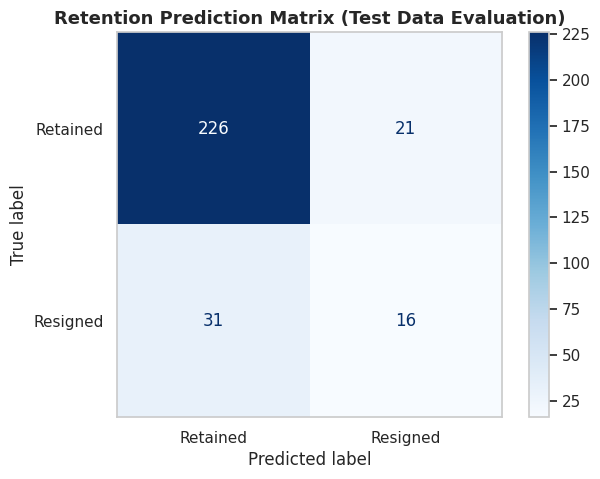

In [15]:
from sklearn.metrics import classification_report , confusion_matrix ,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_predictions = rf_model.predict(X_test)

print("[SYSTEM STATUS] AI Evaluation Metrics:")
print("-" * 50)
print(classification_report(y_test , y_predictions , target_names = ['Retained (0)' , 'Resigned (1)']))
print("-" * 50)

cm = confusion_matrix(y_test , y_predictions )
matrix_visual = ConfusionMatrixDisplay(confusion_matrix = cm , display_labels = ['Retained' , 'Resigned'])

fig, ax = plt.subplots(figsize=(7,5))
matrix_visual.plot(cmap = 'Blues' , ax=ax, values_format='d')
plt.title("Retention Prediction Matrix (Test Data Evaluation)", fontsize=13, fontweight='bold')
plt.grid(False)
plt.show()




# Strategic Recommendation & ROI



The predictive model successfully identifies employees at high risk of attrition. By leveraging the built-in feature importance of the Random Forest
algorithm alongside our synthesized 'Loyalty_Ratio', Human Resources can shift from reactive exit interviews to proactive retention.

* HR should deploy retention bonuses and career -mapping sessions specifically to the top 15% of employees flagged as flight risks by this model.
* Cross-reference model predictions with departmental policies (such as forced overtime) in the Sales and R&D divisions to flight risks by this model.
* By identifying flight risks early, the enterprise can significantly reduce the extensive capital costs associated with recruiting, hiring, and training replacement talent.

In [16]:
import joblib
joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(X_train_balanced.columns, 'model_columns.pkl')

['model_columns.pkl']